#### Load Original Image

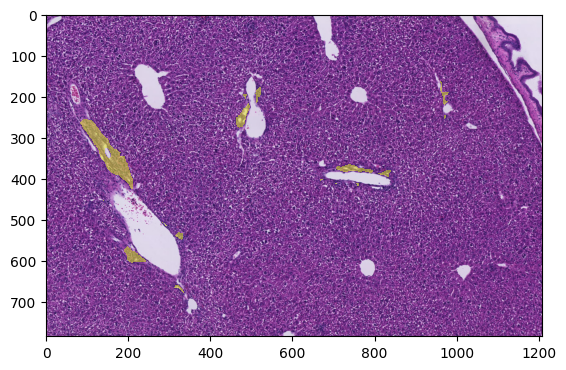

In [1]:
import sys
sys.path.append("..\\src")
import numpy as np
import matplotlib.pyplot as plt
from biliary_seg.data.image_loader import ImageLoader
from biliary_seg.training.augmentations import RandomHEDJitter, training_augmentations

image_loader = ImageLoader.from_data_dir(id='RG425_roi_0', data_dir='..\\data\\processed')

plt.imshow(image_loader.image)
mask = np.ma.masked_where(image_loader.mask == 0, image_loader.mask)
plt.imshow(mask, alpha=0.5, cmap='plasma_r')

#### Sample from HED Jitter

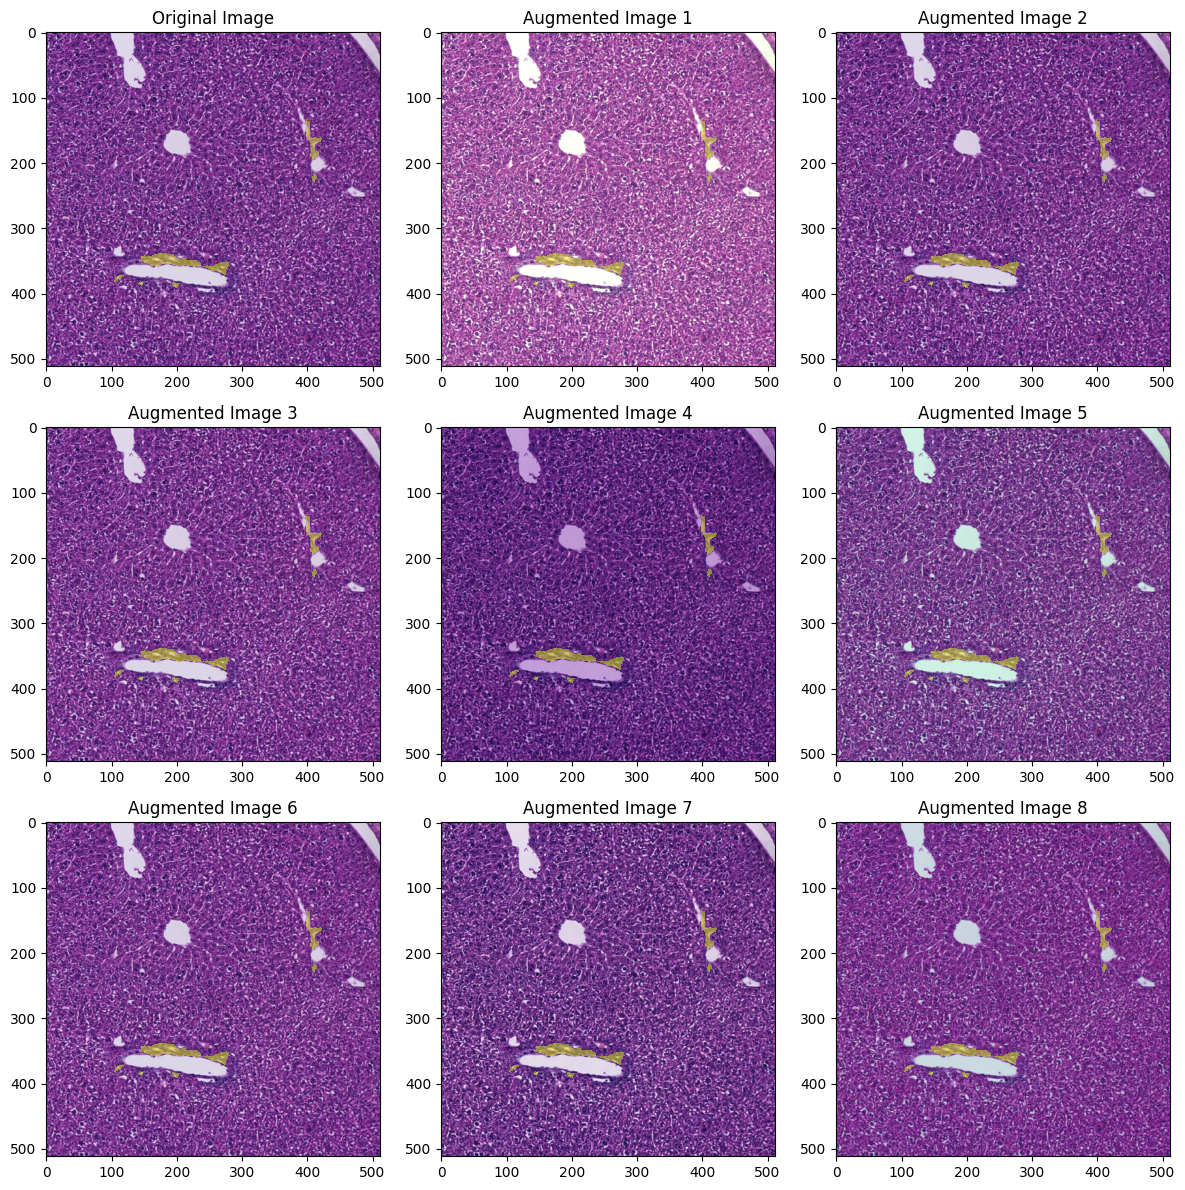

In [5]:
hed_jitter = RandomHEDJitter()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

base_image, mask = image_loader.random_sample(variance_range=None)
for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.set_title("Original Image")
        ax.imshow(base_image)
        masked_mask = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked_mask, alpha=0.5, cmap='plasma_r')
    else:
        aug = hed_jitter(image=base_image, masks=[mask])
        aug_image, aug_mask = aug["image"], aug["masks"][0]
        ax.set_title(f"Augmented Image {i}")
        ax.imshow(aug_image)
        masked_aug_mask = np.ma.masked_where(aug_mask == 0, aug_mask)
        ax.imshow(masked_aug_mask, alpha=0.5, cmap='plasma_r')

fig.tight_layout()

#### Sample from Train Augmentations

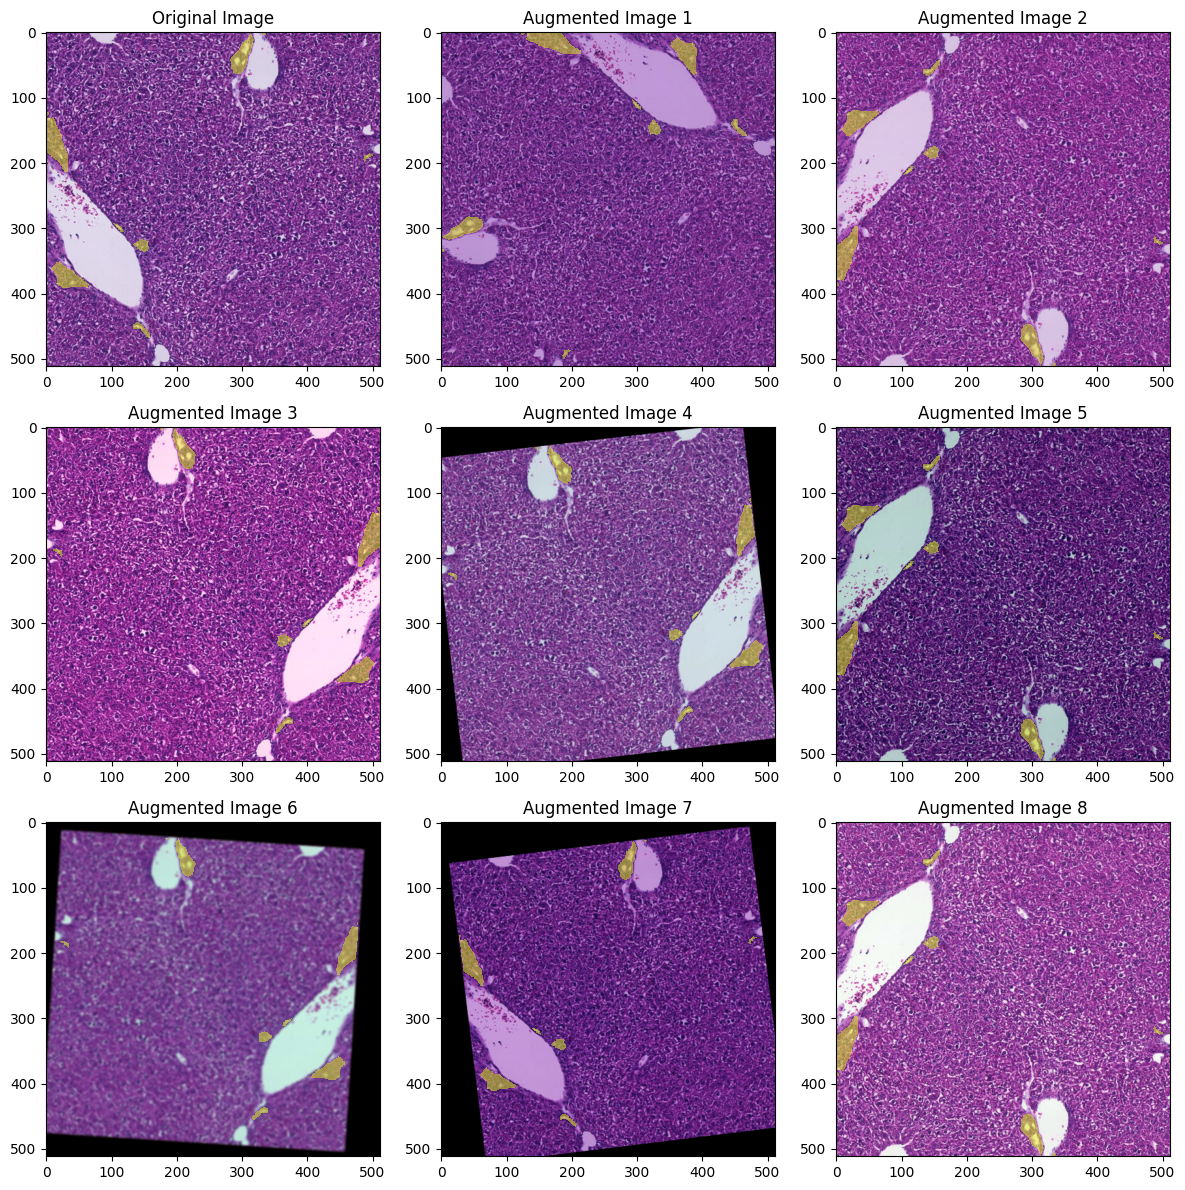

In [6]:
augmentations = training_augmentations

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

base_image, mask = image_loader.random_sample(variance_range=None)
for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.set_title("Original Image")
        ax.imshow(base_image)
        masked_mask = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked_mask, alpha=0.5, cmap='plasma_r')
    else:
        aug = augmentations(image=base_image, masks=[mask])
        aug_image, aug_mask = aug["image"], aug["masks"][0]
        ax.set_title(f"Augmented Image {i}")
        ax.imshow(aug_image)
        masked_aug_mask = np.ma.masked_where(aug_mask == 0, aug_mask)
        ax.imshow(masked_aug_mask, alpha=0.5, cmap='plasma_r')

fig.tight_layout()